# Classification basics with the perceptron

The first classification notebook. It uses the simplest linear classifier there is, the perceptron, to
go through everything that's different about evaluating classifiers:

1. MNIST, and turning it into a binary "is this a 0?" problem
2. why accuracy alone is misleading (baseline with `DummyClassifier`)
3. confusion matrix, precision, recall, F1
4. cross validation for classifiers
5. the precision/recall trade-off, PR and ROC curves
6. multiclass with one-vs-rest
7. loss curves with `partial_fit`, tuning the learning rate
8. what the weights look like

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.dummy import DummyClassifier
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import Perceptron
from sklearn.metrics import (ConfusionMatrixDisplay, classification_report, precision_score, recall_score,
                             f1_score, precision_recall_curve, roc_curve, roc_auc_score, hinge_loss,
                             make_scorer)
from sklearn.model_selection import cross_validate, cross_val_predict, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, LabelBinarizer

warnings.simplefilter("ignore", ConvergenceWarning)

## MNIST

70,000 handwritten digits, each a 28x28 greyscale image flattened into 784 pixel values (0-255).
`fetch_openml` downloads it the first time (about 50 MB) and caches it.

In [2]:
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X.to_numpy()
y = y.to_numpy()

print(f"samples: {X.shape[0]}, features: {X.shape[1]}, pixel range: {X.min():.0f}-{X.max():.0f}")
print("labels:", np.unique(y), "(strings, not ints)")

samples: 70000, features: 784, pixel range: 0-255
labels: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9'] (strings, not ints)


Pixels are 0-255, so scaling to [0, 1] is all the preprocessing needed. The course used `MinMaxScaler`,
which is kept here so the numbers match. Strictly speaking it scales each pixel column by its own maximum,
and a few edge pixels never reach 255, so `X / 255` is the more natural choice for images.

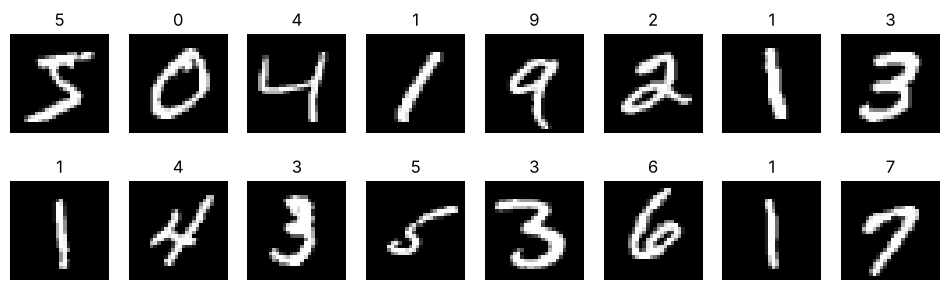

In [3]:
X = MinMaxScaler().fit_transform(X)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for ax, img, label in zip(axes.ravel(), X, y):
    ax.imshow(img.reshape(28, 28), cmap='gray')
    ax.set_title(label)
    ax.axis('off')
plt.show()

The standard split is the first 60,000 images for training and the last 10,000 for test. The data is
already shuffled, so no `train_test_split` needed.

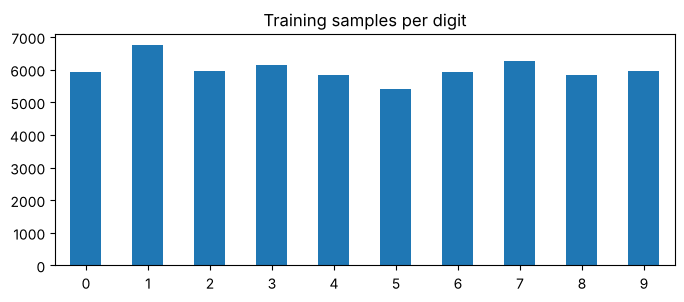

In [4]:
x_train, x_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

pd.Series(y_train).value_counts().sort_index().plot.bar(rot=0, figsize=(8, 3))
plt.title('Training samples per digit')
plt.show()

Roughly balanced across the 10 digits.

## Binary problem: a "0" detector

A single perceptron separates two classes, so start with "is this digit a 0?". For the perceptron, labels
are +1 (it's a 0) and -1 (anything else).

In [5]:
y_train_0 = np.where(y_train == '0', 1, -1)
y_test_0 = np.where(y_test == '0', 1, -1)

print("positives:", (y_train_0 == 1).sum(), " negatives:", (y_train_0 == -1).sum())

positives: 5923  negatives: 54077


## Baseline

Only about 10% of the training images are zeros. A "model" that always says "not a 0" is right 90% of
the time:

In [6]:
base_clf = DummyClassifier(strategy='most_frequent').fit(x_train, y_train_0)
print(f"train accuracy: {base_clf.score(x_train, y_train_0):.4f}")
print(f"test accuracy:  {base_clf.score(x_test, y_test_0):.4f}")

train accuracy: 0.9013
test accuracy:  0.9020


90% accuracy without learning anything (54,077 / 60,000). So accuracy alone is a bad measure when the
classes are imbalanced, and any real model has to be compared against this.

## The perceptron

The model computes a weighted sum and takes its sign:

$$\hat{y} = \text{sign}(\mathbf{w}^T \mathbf{x} + b)$$

Training goes through the data, and whenever a sample is misclassified it nudges the weights towards
getting it right: $\mathbf{w} \leftarrow \mathbf{w} + \eta \, y_i \mathbf{x}_i$. In sklearn this is
SGD on the perceptron loss $\max(0, -y_i \mathbf{w}^T\mathbf{x}_i)$.

Main parameters: `eta0` (learning rate, default 1), `max_iter` (epochs), `penalty` / `alpha` (optional
regularisation), `random_state` (order the samples are shuffled in).

In [7]:
bin_clf = Perceptron(max_iter=100, random_state=1729)
bin_clf.fit(x_train, y_train_0)

print("weights:", bin_clf.coef_.shape, " bias:", bin_clf.intercept_)
print(f"train accuracy: {bin_clf.score(x_train, y_train_0):.4f}")
print(f"test accuracy:  {bin_clf.score(x_test, y_test_0):.4f}")

weights: (1, 784)  bias: [-108.]
train accuracy: 0.9909
test accuracy:  0.9890


99% sounds great, but the baseline was 90%. Need better metrics.

## Confusion matrix, precision and recall

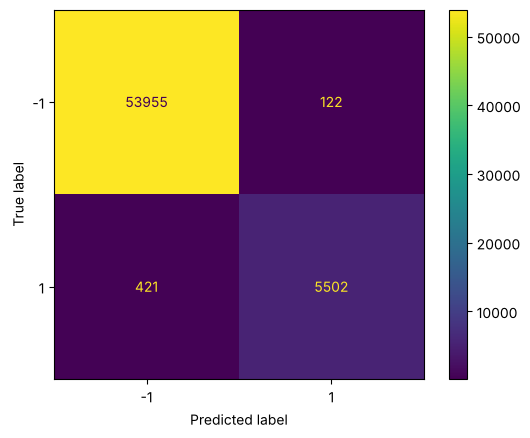

In [8]:
y_hat_train_0 = bin_clf.predict(x_train)
cm_display = ConfusionMatrixDisplay.from_predictions(y_train_0, y_hat_train_0, values_format='d')
plt.show()

In [9]:
(tn, fp), (fn, tp) = cm_display.confusion_matrix

precision = tp / (tp + fp)       # of the images called "0", how many really are
recall = tp / (tp + fn)          # of the real 0s, how many were found
f1 = 2 * precision * recall / (precision + recall)
print(f"precision {precision:.3f}   recall {recall:.3f}   F1 {f1:.3f}")

precision 0.978   recall 0.929   F1 0.953


Which one matters more depends on the cost of each mistake: a spam filter wants high precision (don't
bin real emails), a disease screen wants high recall (don't miss cases). F1 is the harmonic mean, high only
when both are.

`classification_report` gives everything at once, for both classes:

In [10]:
print(classification_report(y_train_0, y_hat_train_0, digits=3))

              precision    recall  f1-score   support

          -1      0.992     0.998     0.995     54077
           1      0.978     0.929     0.953      5923

    accuracy                          0.991     60000
   macro avg      0.985     0.963     0.974     60000
weighted avg      0.991     0.991     0.991     60000



## Cross validation

`cross_validate` with several scoring metrics at once:

In [11]:
scores = cross_validate(Perceptron(max_iter=100, random_state=1729), x_train, y_train_0, cv=5,
                        scoring=['precision', 'recall', 'f1'])
for m in ['precision', 'recall', 'f1']:
    print(f"{m:9s} {scores['test_' + m].mean():.3f} +/- {scores['test_' + m].std():.3f}")

precision 0.963 +/- 0.013
recall    0.924 +/- 0.035
f1        0.942 +/- 0.013


Recall varies most between folds. `cross_val_predict` is another way: every training sample gets a
prediction from the fold where it was held out, so you can build one confusion matrix for the whole
training set without any of it being "seen" data.

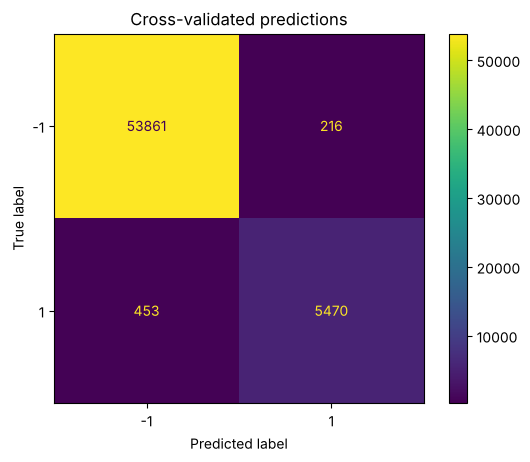

              precision    recall  f1-score   support

          -1      0.992     0.996     0.994     54077
           1      0.962     0.924     0.942      5923

    accuracy                          0.989     60000
   macro avg      0.977     0.960     0.968     60000
weighted avg      0.989     0.989     0.989     60000



In [12]:
y_hat_cv = cross_val_predict(Perceptron(max_iter=100, random_state=1729), x_train, y_train_0, cv=5)
ConfusionMatrixDisplay.from_predictions(y_train_0, y_hat_cv, values_format='d')
plt.title('Cross-validated predictions')
plt.show()
print(classification_report(y_train_0, y_hat_cv, digits=3))

And on the test set, once:

In [13]:
y_hat_test_0 = bin_clf.predict(x_test)
print(f"test precision {precision_score(y_test_0, y_hat_test_0):.3f}   "
      f"recall {recall_score(y_test_0, y_hat_test_0):.3f}   F1 {f1_score(y_test_0, y_hat_test_0):.3f}")

test precision 0.967   recall 0.919   F1 0.942


## Precision/recall trade-off

`predict` thresholds the score $\mathbf{w}^T\mathbf{x} + b$ at 0. `decision_function` gives the raw score,
and moving the threshold trades precision for recall. Higher threshold: fewer images called "0", so
fewer false positives (precision up) but more missed zeros (recall down).

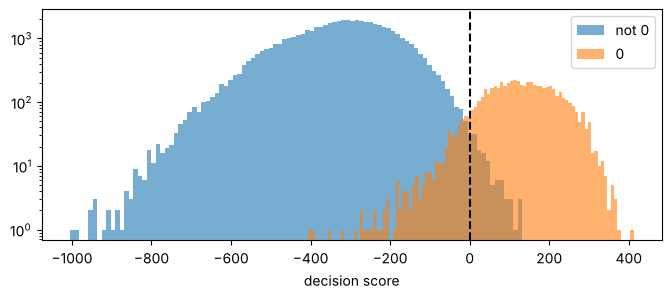

In [14]:
y_scores = bin_clf.decision_function(x_train)

plt.figure(figsize=(8, 3))
plt.hist(y_scores[y_train_0 == -1], bins=100, alpha=0.6, label='not 0')
plt.hist(y_scores[y_train_0 == 1], bins=100, alpha=0.6, label='0')
plt.axvline(0, c='k', ls='--')
plt.xlabel('decision score'); plt.legend(); plt.yscale('log')
plt.show()

Most scores are negative because 90% of the images aren't zeros. (Log scale on the y axis, otherwise the
positives are invisible.)

`precision_recall_curve` needs these scores, **not** the predicted labels:

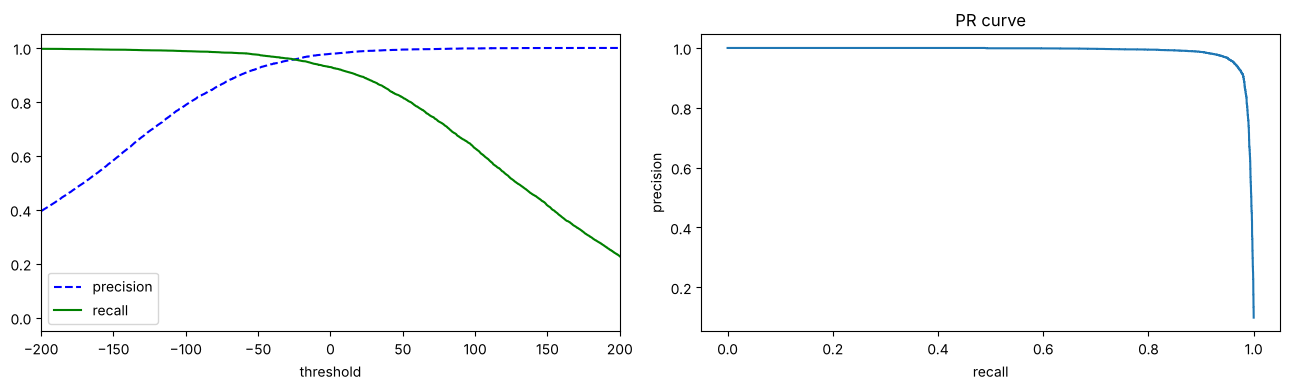

In [15]:
precisions, recalls, thresholds = precision_recall_curve(y_train_0, y_scores)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(thresholds, precisions[:-1], 'b--', label='precision')
axes[0].plot(thresholds, recalls[:-1], 'g-', label='recall')
axes[0].set_xlabel('threshold'); axes[0].legend(); axes[0].set_xlim(-200, 200)
axes[1].plot(recalls, precisions)
axes[1].set_xlabel('recall'); axes[1].set_ylabel('precision'); axes[1].set_title('PR curve')
plt.tight_layout()
plt.show()

To get higher precision, pick a threshold above 0:

In [16]:
y_hat_thresh = np.where(y_scores > 20, 1, -1)
print(f"threshold 0:  precision {precision_score(y_train_0, y_hat_train_0):.3f}  recall {recall_score(y_train_0, y_hat_train_0):.3f}")
print(f"threshold 20: precision {precision_score(y_train_0, y_hat_thresh):.3f}  recall {recall_score(y_train_0, y_hat_thresh):.3f}")

threshold 0:  precision 0.978  recall 0.929
threshold 20: precision 0.988  recall 0.897


In a real project the threshold would be chosen on validation data (or with cross-validated scores), not
on the same training predictions.

### ROC curve

True positive rate (recall) against false positive rate for every threshold. The diagonal is a random
classifier, and the area under the curve (AUC) summarises it in one number.

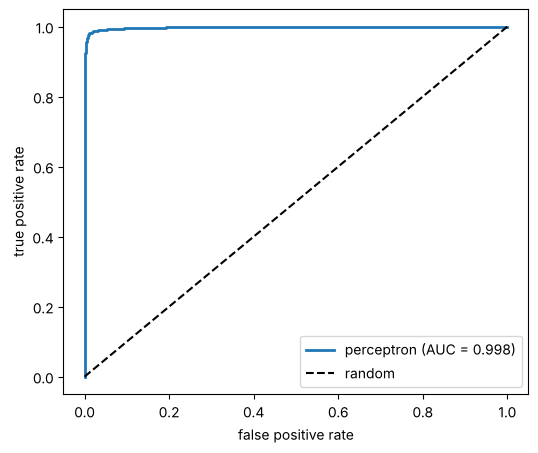

In [17]:
fpr, tpr, _ = roc_curve(y_train_0, y_scores)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, lw=2, label=f'perceptron (AUC = {roc_auc_score(y_train_0, y_scores):.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='random')
plt.xlabel('false positive rate'); plt.ylabel('true positive rate'); plt.legend()
plt.show()

With heavily imbalanced classes the ROC curve can look great even when precision is poor, because the
false positive rate is divided by the huge number of negatives. The PR curve is more informative then.

## Warm start vs cold start

Calling `fit` again normally starts from scratch, so the result is identical every time (same
`random_state`). With `warm_start=True` the next `fit` continues from the current weights.

In [18]:
cold = Perceptron(max_iter=5, random_state=1729)
warm = Perceptron(max_iter=5, random_state=1729, warm_start=True)
for i in range(3):
    cold.fit(x_train, y_train_0)
    warm.fit(x_train, y_train_0)
    print(f"fit #{i + 1}: cold {cold.score(x_train, y_train_0):.4f}   warm {warm.score(x_train, y_train_0):.4f}")

fit #1: cold 0.9906   warm 0.9906


fit #2: cold 0.9906   warm 0.9890


fit #3: cold 0.9906   warm 0.9893


## Loss curve with partial_fit

`partial_fit` does exactly one pass over the data per call, so the loss can be recorded after each one.
The first call needs the list of classes.

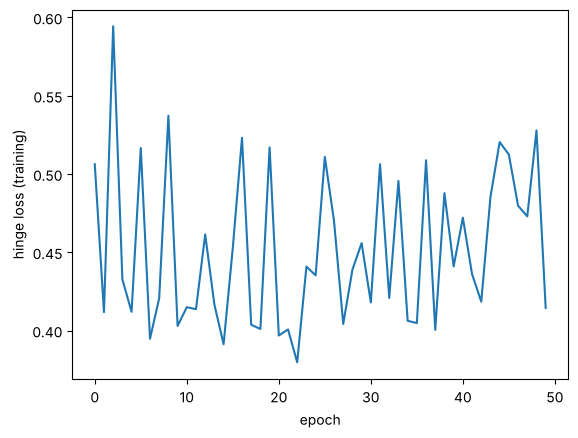

In [19]:
def loss_curve(eta0, epochs=50):
    clf = Perceptron(eta0=eta0, random_state=2094)
    losses = []
    for _ in range(epochs):
        clf.partial_fit(x_train, y_train_0, classes=np.array([-1, 1]))
        losses.append(hinge_loss(y_train_0, clf.decision_function(x_train)))
    return losses

loss_eta1 = loss_curve(1.0)
plt.plot(loss_eta1)
plt.xlabel('epoch'); plt.ylabel('hinge loss (training)')
plt.show()

It never reaches zero: zeros and non-zeros aren't perfectly linearly separable, so the perceptron keeps
finding mistakes to correct and the loss jumps around.

### Tuning the learning rate

In [20]:
eta_grid = [1 / 2 ** n for n in range(0, 6)]
search = GridSearchCV(Perceptron(random_state=1729), param_grid={"eta0": eta_grid},
                      scoring=make_scorer(hinge_loss, greater_is_better=False), cv=5)
search.fit(x_train, y_train_0)

res = pd.DataFrame({'eta0': eta_grid, 'mean hinge loss': -search.cv_results_['mean_test_score']})
print("best:", search.best_params_)
res.round(4)

best: {'eta0': 0.03125}


,eta0,mean hinge loss
0,1.0000,0.0223
1,0.5000,0.0223
2,0.2500,0.0223
3,0.1250,0.0215
4,0.0625,0.0223
5,0.0312,0.0207


Hinge loss is computed on the predicted *labels* here (`make_scorer` passes `predict` output, not
`decision_function`), so it's effectively a scaled error rate. With scores in {-1, +1} it's 2 for every
mistake and 0 otherwise.

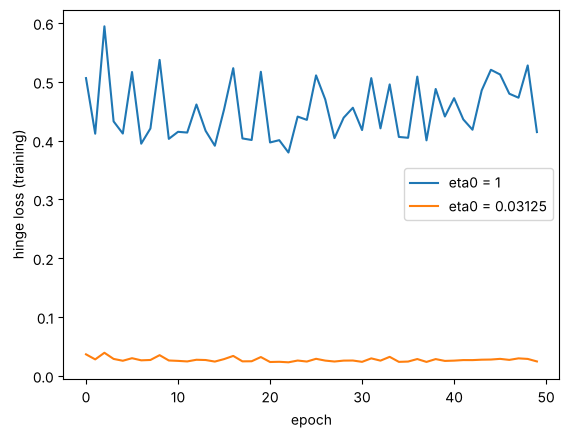

In [21]:
plt.plot(loss_eta1, label='eta0 = 1')
plt.plot(loss_curve(search.best_params_['eta0']), label=f"eta0 = {search.best_params_['eta0']}")
plt.xlabel('epoch'); plt.ylabel('hinge loss (training)'); plt.legend()
plt.show()

All the values are within about 0.002 of each other, i.e. a difference of roughly 0.1% in error rate.
For a plain perceptron with no regularisation that's expected: every update is a multiple of `eta0` and
the weights start at 0, so changing `eta0` just scales all the weights and leaves the predictions the
same. The small differences come from the stopping rule (`tol` compares loss values whose size depends on
`eta0`, so runs stop after different numbers of epochs). The course picked 0.125, this run picks 0.03125,
neither choice really matters.

## Multiclass: one-vs-rest

Pass all 10 labels and sklearn trains 10 binary perceptrons, one per digit ("0 vs rest", "1 vs rest",
...). To predict, every classifier scores the image and the highest score wins.

In [22]:
LabelBinarizer().fit_transform(y_train[:5]), y_train[:5]

(array([[0, 0, 0, 1, 0],
        [1, 0, 0, 0, 0],
        [0, 0, 1, 0, 0],
        [0, 1, 0, 0, 0],
        [0, 0, 0, 0, 1]]),
 array(['5', '0', '4', '1', '9'], dtype=object))

In [23]:
clf = Perceptron(random_state=1729).fit(x_train, y_train)
print("weight matrix:", clf.coef_.shape, " biases:", clf.intercept_.shape)

scores6 = clf.decision_function(x_train[6:7])
print("scores for one image:", scores6.round(1))
print("predicted:", clf.classes_[np.argmax(scores6)], " actual:", y_train[6])

weight matrix: (10, 784)  biases: (10,)
scores for one image: [[-631.9  154.4  -65.2  -91.  -189.3 -137.1  -99.6 -159.1 -136.9 -199.3]]
predicted: 1  actual: 1


In [24]:
y_hat = clf.predict(x_test)
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       980
           1       0.95      0.99      0.97      1135
           2       0.90      0.88      0.89      1032
           3       0.85      0.88      0.86      1010
           4       0.87      0.93      0.90       982
           5       0.80      0.87      0.83       892
           6       0.90      0.95      0.93       958
           7       0.90      0.91      0.90      1028
           8       0.90      0.78      0.83       974
           9       0.91      0.82      0.86      1009

    accuracy                           0.90     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.90      0.90      0.89     10000



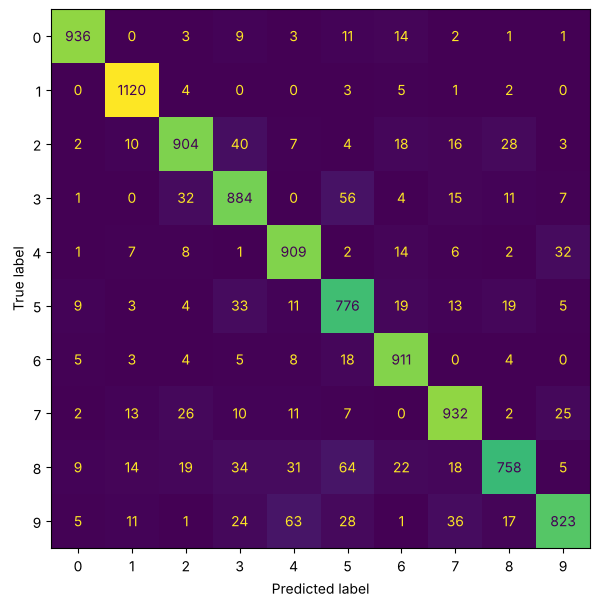

In [25]:
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay.from_predictions(y_test, y_hat, values_format='d', ax=ax, colorbar=False)
plt.show()

About 90% accuracy with ten linear classifiers. The biggest mix-ups in the confusion matrix: 5 read as 3
or 8, 9 read as 4, and 2 read as 3 or 8. Digits that share curves and loops.

## What the 0-detector learned

Each weight multiplies one pixel, so the weight vector can be shown as an image. Blue = positive weight
(evidence for "0"), red = negative (evidence against).

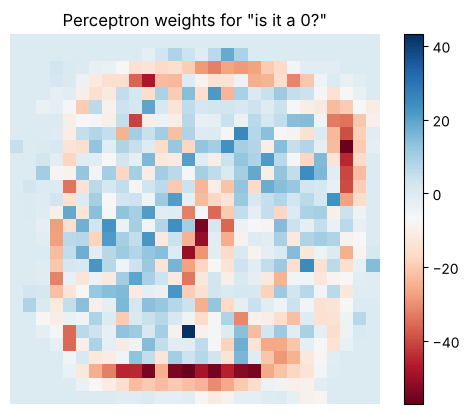

In [26]:
plt.imshow(bin_clf.coef_.reshape(28, 28), cmap='RdBu')
plt.colorbar(); plt.axis('off')
plt.title('Perceptron weights for "is it a 0?"')
plt.show()

Strongly negative weights in the centre, where a 0 is empty but 1s, 7s and 4s have strokes, and along the
outer edge of the drawing area. The positive weights are scattered through the band where a 0's loop
usually runs. It's noisy: the perceptron only updates on mistakes and stops as soon as a point is on the
right side, so nothing smooths the weights out.

A false positive and a true negative, showing pixel x weight (what each pixel contributed to the score):

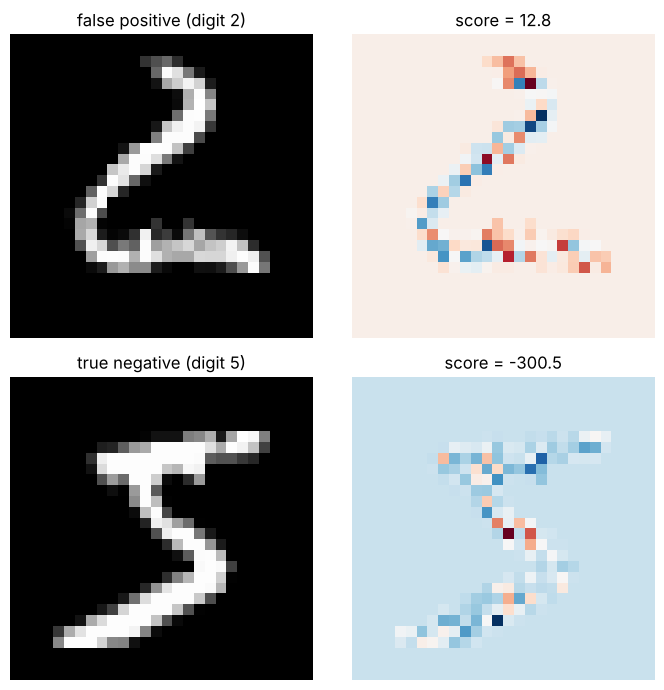

In [27]:
fp_idx = np.where((y_train_0 == -1) & (y_hat_train_0 == 1))[0][0]
tn_idx = np.where((y_train_0 == -1) & (y_hat_train_0 == -1))[0][0]

fig, axes = plt.subplots(2, 2, figsize=(7, 7))
for row, idx, name in [(0, fp_idx, 'false positive'), (1, tn_idx, 'true negative')]:
    contrib = bin_clf.coef_.ravel() * x_train[idx]
    axes[row, 0].imshow(x_train[idx].reshape(28, 28), cmap='gray')
    axes[row, 0].set_title(f"{name} (digit {y_train[idx]})")
    axes[row, 1].imshow(contrib.reshape(28, 28), cmap='RdBu')
    axes[row, 1].set_title(f"score = {contrib.sum() + bin_clf.intercept_[0]:.1f}")
    for ax in axes[row]:
        ax.axis('off')
plt.tight_layout()
plt.show()

## A mistake to avoid: refitting on the test set

The original notebook had a side experiment with PCA where it called `pca.fit(x_test)` before transforming
the test set. That fits a *different* PCA to the test data, so the test features no longer mean the same
thing as the training features the classifier learned from. Transformers are fitted on training data only
and then reused, the same rule as for scalers. A pipeline makes it automatic:

In [28]:
from sklearn.decomposition import PCA

pca_clf = Pipeline([('pca', PCA(n_components=10, random_state=1)), ('clf', Perceptron(random_state=42))])
pca_clf.fit(x_train, y_train_0)
print(f"test F1 with PCA fitted on train only: {f1_score(y_test_0, pca_clf.predict(x_test)):.3f}")

test F1 with PCA fitted on train only: 0.807


## Summary

* with imbalanced classes, accuracy is misleading. Compare against a `DummyClassifier`
* confusion matrix, precision, recall and F1 describe what kind of mistakes a model makes
* `decision_function` + a threshold lets you trade precision for recall. PR and ROC curves show every option
* sklearn handles multiclass for binary models with one-vs-rest automatically
* `partial_fit` gives you control over training epoch by epoch